# Tutorial 1 : Diffusion coefficients from financial data

In financial modeling, asset prices are often represented using continuous-time stochastic processes to capture the randomness observed in markets. A widely used model is the geometric Brownian motion (GBM), which serves as the foundation for the [Black-Scholes](https://fr.wikipedia.org/wiki/Mod%C3%A8le_Black-Scholes) option pricing framework. In such models, the diffusion coefficient plays a central role: it quantifies the magnitude of randomness or volatility in asset returns. Mathematically, the diffusion coefficient appears as the multiplier of the Brownian motion term in a stochastic differential equation (SDE) :

$$ \delta x_t=b \delta t +\sqrt{2D \delta t} \eta_t $$

where $(\eta_t)_t$ is Gaussian white noise, $D$ the diffusion coefficient (or volatility), $b$ a bias, and $S_t=e^{x_t}=e^{\int_0^t \delta x_{t'}}$ is the option price.

This TD aims to introduce the concept of diffusion coefficients, explore their interpretation in financial contexts through the example of the [S&P](https://fr.wikipedia.org/wiki/S%26P_500)  and [Nikkei 225](https://fr.wikipedia.org/wiki/Nikkei_225) indices, and guide you through examples involving their computation and estimation.

![Trading.png](Trading.png)

In [24]:
#!pip install yfinance

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
#import yfinance as yf
import pandas as pd

# Set global font sizes for labels and ticks
plt.rcParams['axes.labelsize'] = 20    # axis labels (xlabel, ylabel)
plt.rcParams['xtick.labelsize'] = 16   # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 16   # y-axis tick labels

### Reading the data
Here's a script to read the two data files using `pd.read_csv` of the pandas library, `spx_data.csv` ([S&P index](https://fr.wikipedia.org/wiki/S%26P_500)) and `n225_data.csv` ([Nikkei 225](https://fr.wikipedia.org/wiki/Nikkei_225)). 

### Question 1: 
Plot the trajectories. Compare with the trajectories once taken to the $\log_{10}$. What are their characteristics? How do they fill the space? 

In [26]:
spx_data=pd.read_csv('spx_data.csv')
t_spx=list(spx_data['Days'])
l_spx=list(spx_data['Index'])
l_spx=[float(l) for l in l_spx]

n225_data=pd.read_csv('n225_data.csv')
t_n225=list(n225_data['Days'])
l_n225=list(n225_data['Index'])
l_n225=[float(l) for l in l_n225]

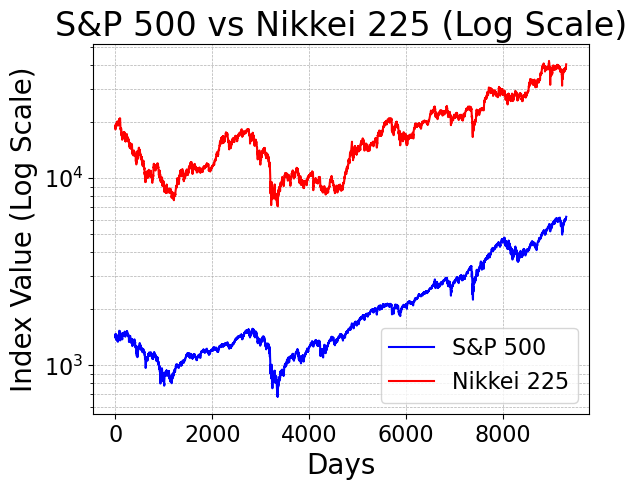

In [27]:
plt.plot(t_spx, l_spx, label='S&P 500', color='blue')
plt.plot(t_n225, l_n225, label='Nikkei 225', color='red')
plt.yscale('log')
plt.title('S&P 500 vs Nikkei 225 (Log Scale)', fontsize=24)
plt.xlabel('Days', fontsize=20)
plt.ylabel('Index Value (Log Scale)', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### Question 2: Estimation of the diffusion coefficient $D$

In the rest of the tutorial, we suppose that $b=0$. The random-walk relation between displacement and time in one dimension, defining the diffusion
coefficient $D$, is the Gaussian distribution:
$$ \mathbb{P}(\delta x|\delta t, D)=\frac{1}{\sqrt{4\pi D \delta t}}e^{-\delta x^2/4D \delta t}$$
so at each step of duration $δt$ the mean displacement is $< δx >= 0$ and its variance $< δx^2 >= 2Dδt$.
Give a rough estimation of the diffusion coefficient from the data using two methods.

#### Question 2 (i): 
Give a rough estimation of the diffusion coefficient from the data (using the first and last data points).

$$
    D \approx \frac{(X_T - X_0)^2}{2(T-0)}
$$

In [40]:
log_price = np.log(l_spx)
log_n225 = np.log(l_n225)

In [41]:
Dspx1 = (log_price[-1] - log_price[0])**2 / (2 * (t_spx[-1] - t_spx[0]))
print(f"Estimated diffusion coefficient D for S&P 500: {Dspx1:.6f} /day")
Dn225 = (log_n225[-1] - log_n225[0])**2 / (2 * (t_n225[-1] - t_n225[0]))
print(f"Estimated diffusion coefficient D for Nikkei 225: {Dn225:.6f} /day")

Estimated diffusion coefficient D for S&P 500: 0.000113 /day
Estimated diffusion coefficient D for Nikkei 225: 0.000031 /day


#### Question 2 (ii): 
Give another method to estimate of the diffusion coefficient using all the data points.

In [44]:
diff_data = np.diff(log_price)
timediff = np.diff(t_spx)
dr2 = diff_data**2
Dspx2 = np.mean(dr2 / (2*timediff))
print(f"Estimated diffusion coefficient D for S&P 500: {Dspx2:.6f} /day")

Dn225_2 = np.mean(np.diff(log_n225)**2 / (2*np.diff(t_n225)))
print(f"Estimated diffusion coefficient D for Nikkei 225: {Dn225_2:.6f} /day")

Estimated diffusion coefficient D for S&P 500: 0.000063 /day
Estimated diffusion coefficient D for Nikkei 225: 0.000086 /day


### Question 3: Maximum-likelihood method:

Write down the probability density $P(\lbrace δx_i \rbrace |D, \lbrace δt_i \rbrace)$ where $δx_i = x_{i} − x_{i−1}$ , $δt_i = t_i − t_{i−1}$ of
the time series $(x_i)_{i=0,...,M-1}$, given $D$ and the measurement times, and deduce, using Bayes rule (uniform prior), the
posterior density of probability for the diffusion coefficient, $P (D|\lbrace \delta t_i , \delta x_i \rbrace_{i=1,...,M-1})$.

### Question 4: Analytical computation:

We note $N=M-1$. Calculate analytically (assuming a uniform prior on $D$):

#### Question 4 (i): 
the most likely value of the diffusion coefficient
$$
    D^* = \frac{1}{2N} \sum_{i=0}^N \frac{\delta x_i^2}{\delta t_i}
$$

#### Question 4 (ii): 
its average value
$$
    \langle D \rangle = \frac{B}{N - 4}
$$

#### Question 4 (iii): 
its variance
$$
    \mathrm{Var}(D) = \langle D^2 \rangle - \langle D \rangle^2 = \frac{B^2}{(N-4)(N-6)} - \frac{B^2}{(N - 4)^2} = \frac{2B^2}{(N-4)^2 (N-6)}
$$

### Question 5: Posterior computation 

Plot the posterior distribution of $D$ obtained from the two data files. Compute, for the given datasets,
the values of the mean and of the variance of $D$, and its most likely value. Compare the results obtained
with different number $M$ of measures ($M=100$, $M=1000$ and all the data). 

**Hint:** To compute the likelihood, use Stirling's formula,

$$ n!\sim n^{n}e^{-n}\sqrt{2 \pi n} $$

The posterior is given by
$$
    p(D | \{\delta x_i, \delta t_i\}) = e^{-\frac{B}{2D}} D^{-\frac{N}{2}} C
$$
where $N = M-1$ and
$$
    C = \left(\frac{B}{2}\right)^{1 - \frac{N}{2}} \Gamma\left(\frac{N}{2} - 1\right)
$$
and
$$
    B = \frac{1}{2} \sum_{i=1}^N \frac{\delta x_i^2}{\delta t_i}
$$

/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_13731/834468485.py:8: RuntimeWarning: overflow encountered in multiply
  pds = np.exp(-B / (2*ds)) * (ds)**(-N/2) * C
/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_13731/834468485.py:5: RuntimeWarning: overflow encountered in scalar power
  C = (B/2)**(1 - N/2) * (N / np.exp(1))**N  * np.sqrt(2 * np.pi * N)
/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_13731/834468485.py:8: RuntimeWarning: overflow encountered in power
  pds = np.exp(-B / (2*ds)) * (ds)**(-N/2) * C
/var/folders/hr/wt83vx857tb5stw6bpqw6ss00000gn/T/ipykernel_13731/834468485.py:8: RuntimeWarning: invalid value encountered in multiply
  pds = np.exp(-B / (2*ds)) * (ds)**(-N/2) * C


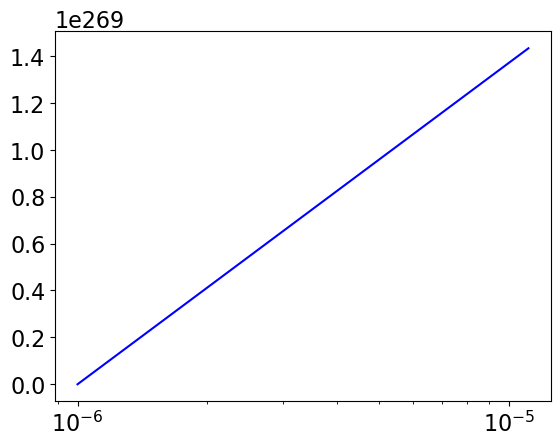

In [69]:
Ms = [100, 1000]
for M in Ms:
    N = M-1
    B = sum(diff_data[:M]**2 / timediff[:M])/2
    C = (B/2)**(1 - N/2) * (N / np.exp(1))**N  * np.sqrt(2 * np.pi * N)
    # C = 1e-170
    ds = np.linspace(10**(-6), 10**(-3), M)
    pds = np.exp(-B / (2*ds)) * (ds)**(-N/2) * C
    
    plt.plot(ds, pds, color="blue")
    plt.xscale("log")
    

### Question 6: Test of the bias 

In this section, we are interested in testing wether the bias in the dataset was indeed neglictible or not for the purpose of our analysis. To this end, we are going to perform an hypothesis testing of $H_0:$" the bias is 0 " versus $H_1:$ "the bias is non zero". 

#### Question 6 (i) 
Justify that, under $H_0$, the random variables $\delta x_i/\sqrt{\delta t_i}$ are i.i.d. Gaussian variables of mean 0 and variance $2D$. This implies that $\vec{X}=(\frac{\delta x_i}{\sqrt{\delta t_i}})_{i=1,...,\tilde{M}}$ is a gaussian vector with i.i.d. centered gaussian entries (with equal standard deviations).

#### Question 6 (ii) 
We will be using the following theorem which is crucial for Gaussian random variables: 

<div class="alert alert-info">

**Cochran Theorem**

Let $P_F$ be an orthogonal $\tilde{M} \times \tilde{M}$ projection matrix (symetric and $P_F^2=P_F$) on the $d-$dimensional vectorial space $F$ and $\vec{X}$ a vector with i.i.d. gaussian entries. Then, $P_F \vec{X}$ and $(I_{\tilde{M}}-P_F)\vec{X}$ are independent Gaussian vectors.

</div>

Justify that $\hat{X}_{\tilde{M}}=\sum_{i=1}^{\tilde{M}} \frac{\delta x_i}{\sqrt{\delta t_i}}$ and $\hat{s}^2_{\tilde{M}}=\frac{1}{\tilde{M}-1}\sum_{i=1}^{\tilde{M}}(\frac{\delta x_i}{\sqrt{\delta t_i}}-\hat{X}_{\tilde{M}})^2$ are independent random variables (under the hypothesis $H_0$). Compute their means.

**Hint**: $P_F$ is simple.

#### Question 6 (iii) 
$\sqrt{\tilde{M}}\hat{X}_{\tilde{M}}/\hat{s}_{\tilde{M}}$ is a random variable independent of $D$. Its law is called the [Student's t-distribution](https://en.wikipedia.org/wiki/Student%27s_t-distribution) (of $\tilde{M}-1$ degrees of liberty) available in the package `scipy.stats.t`. Compute the probability (still under $H_0$) to observe a value of $|\sqrt{\tilde{M}}\hat{X}_{\tilde{M}}/\hat{s}_{\tilde{M}}|$ as large as the one observed in the dataset. This probability is called the $p-value$, it corresponds to the probability to observe an event as "extreme" as the one observed. We reject $H_0$ if the $p-value$ is small (typically smaller than $0.05$ for 5% risk). Check wether we reject the existence of a bias or not.